In [1]:
import pandas as pd


In [2]:

def load_csv(file):
    try:
        return pd.read_csv(file, engine="python", on_bad_lines="skip", encoding="utf-8")
    except:
        return pd.read_csv(file, engine="python", on_bad_lines="skip", encoding="latin1")

orders = load_csv("orders_dataset.csv")
order_items = load_csv("order_items_dataset.csv")
payments = load_csv("order_payments_dataset.csv")
reviews = load_csv("order_reviews_dataset.csv")

In [3]:
payment_per_order = payments.groupby('order_id')['payment_value'].sum().reset_index()

data = orders.merge(payment_per_order, on='order_id', how='left')

# delet  missing values
data = data.dropna(subset=['payment_value'])

data.rename(columns={'payment_value': 'revenue'}, inplace=True)

In [4]:
text_data = reviews[['order_id', 'review_comment_message']].copy()

# delet  missing values
text_data = text_data.dropna(subset=['review_comment_message'])

In [5]:
#clean text data
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

text_data['clean_review'] = text_data['review_comment_message'].apply(clean_text)



##Using FinBERT

In [6]:
!pip install transformers torch

In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [8]:
def finbert_batch(texts, batch_size=64):
    all_scores = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.nn.functional.softmax(outputs.logits, dim=1)

        scores = probs[:, 2] - probs[:, 0]

        all_scores.extend(scores.cpu().numpy())

    return all_scores

In [9]:
texts = text_data['clean_review'].tolist()

text_data['finbert_score'] = finbert_batch(texts)

##Feature Engineering

In [15]:
#Add review score feature to the data
review_score_df = reviews[['order_id', 'review_score']].copy()

# hanndle missing
review_score_df['review_score'] = review_score_df['review_score'].fillna(
    review_score_df['review_score'].median()
)

In [16]:
review_score_agg = review_score_df.groupby('order_id')['review_score'].mean().reset_index()

In [17]:
#Merge review_score feature with data
data = data.merge(review_score_agg, on='order_id', how='left')

# Handle missing After merge
data['review_score'] = data['review_score'].fillna(data['review_score'].median())

In [10]:
text_data['review_length'] = text_data['clean_review'].apply(lambda x: len(x.split()))

text_data['is_positive'] = text_data['finbert_score'].apply(lambda x: 1 if x > 0 else 0)

In [11]:
#Aggregate by order_id
text_features = text_data.groupby('order_id').agg({
    'finbert_score': 'mean',
    'review_length': 'mean',
    'is_positive': 'mean'
}).reset_index()

In [12]:
#merge text features with data
data = data.merge(text_features, on='order_id', how='left')

# missing handling
data[['finbert_score', 'review_length', 'is_positive']] = \
data[['finbert_score', 'review_length', 'is_positive']].fillna(0)

In [18]:
#add sentiment_review_interaction feature
data['sentiment_review_interaction'] = data['finbert_score'] * data['review_score']

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1098 entries, 0 to 1097
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       1098 non-null   object 
 1   customer_id                    1098 non-null   object 
 2   order_status                   1098 non-null   object 
 3   order_purchase_timestamp       1098 non-null   object 
 4   order_approved_at              1095 non-null   object 
 5   order_delivered_carrier_date   1072 non-null   object 
 6   order_delivered_customer_date  1058 non-null   object 
 7   order_estimated_delivery_date  1098 non-null   object 
 8   revenue                        1098 non-null   float64
 9   finbert_score                  1098 non-null   float32
 10  review_length                  1098 non-null   float64
 11  is_positive                    1098 non-null   float64
 12  review_score                   1098 non-null   f

In [20]:
#Selected Features
features = [
    'finbert_score',
    'review_score',
    'review_length',
    'is_positive',
    'sentiment_review_interaction'
]

In [21]:
#Build X,y
X = data[features]
y = data['revenue']

In [22]:
#Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [23]:
#Spliting the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##ML Models

In [24]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

rf = RandomForestRegressor(n_estimators=200)
gb = GradientBoostingRegressor()
xgb = XGBRegressor()

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
xgb.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

##Deep Learning Models

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model_ann = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model_ann.compile(optimizer='adam', loss='mse')

model_ann.fit(X_train, y_train, epochs=30, batch_size=128, verbose=1)

y_pred_ann = model_ann.predict(X_test).flatten()

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 51461.3711
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51439.2500 
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51415.3789 
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51386.8203 
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 51347.8398 
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 51299.5117  
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51231.4688 
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51158.2539 
Epoch 9/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51060.9062 
Epoch 10/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 50945.7227 
Epoch 11/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 50799.6133 
Epoch 12/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 50622.6602 
Epoch 13/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 50407.2969 
Epoch 14/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 50142.1602 
Epoch 15/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5

In [26]:
#CNN
from tensorflow.keras.layers import Conv1D, Flatten

X_train_cnn = X_train.reshape(-1, X_train.shape[1], 1)
X_test_cnn = X_test.reshape(-1, X_test.shape[1], 1)

model_cnn = Sequential([
    Input(shape=(X_train.shape[1],1)),
    Conv1D(32, 2, activation='relu'),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])

model_cnn.compile(optimizer='adam', loss='mse')

model_cnn.fit(X_train_cnn, y_train, epochs=20, batch_size=128, verbose=1)

y_pred_cnn = model_cnn.predict(X_test_cnn).flatten()

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - loss: 51438.3477
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51400.1602 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51355.5273 
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51304.7930 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51239.0117 
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51151.3125 
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51045.2852 
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 50885.8242 
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 50709.6172 
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 50477.7969 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 50172.0469 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 49831.5625 
Epoch 13/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 49408.7461 
Epoch 14/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 48906.1836 
Epoch 15/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5m

##Evaluation


In [27]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def safe_eval(name, y_true, y_pred):
    y_true = np.nan_to_num(np.array(y_true))
    y_pred = np.nan_to_num(np.array(y_pred))

    mask = (~np.isnan(y_true)) & (~np.isnan(y_pred))

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    print(f"\n===== {name} =====")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2  :", r2_score(y_true, y_pred))

safe_eval("RF", y_test, y_pred_rf)
safe_eval("GB", y_test, y_pred_gb)
safe_eval("XGB", y_test, y_pred_xgb)
safe_eval("ANN", y_test, y_pred_ann)
safe_eval("CNN", y_test, y_pred_cnn)


===== RF =====
MAE : 110.67847437344355
RMSE: 220.62252401889705
R2  : -0.031881292709986075

===== GB =====
MAE : 110.40884967746253
RMSE: 220.83968528219918
R2  : -0.033913677486961946

===== XGB =====
MAE : 110.51734679967707
RMSE: 217.61598014100895
R2  : -0.00394890121638114

===== ANN =====
MAE : 109.75468818456477
RMSE: 238.1564586301313
R2  : -0.20241606203622386

===== CNN =====
MAE : 133.0663518777327
RMSE: 251.9079412874923
R2  : -0.3452833240742834


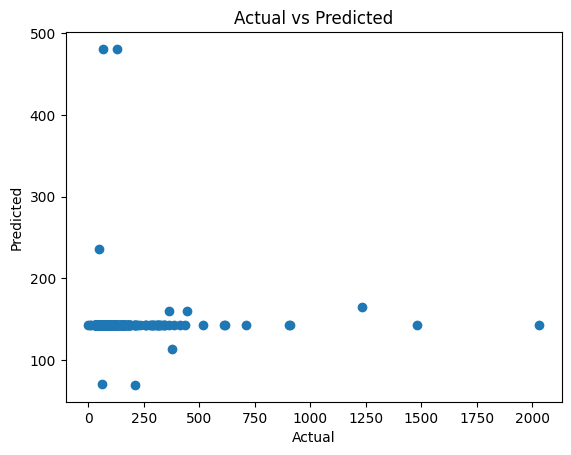

In [28]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred_gb)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()